In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from src.python import tech_colors, ssp_colors

# Set LaTeX style
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Liberation Serif'],
    'mathtext.fontset': 'stix',
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'legend.fontsize': 10,
    'legend.title_fontsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.4,
    'grid.alpha': 0.2,
    'lines.linewidth': 1.5,
})


In [3]:
df_invest = pd.read_csv("output/design/investment_details.csv")

ssps = [s for s in df_invest['SSP'].unique() if s != 'past']
techs = [s for s in df_invest['Technology'].unique()]

prod_type = ['GSHP','ASHP','E_boiler','NG_boiler']

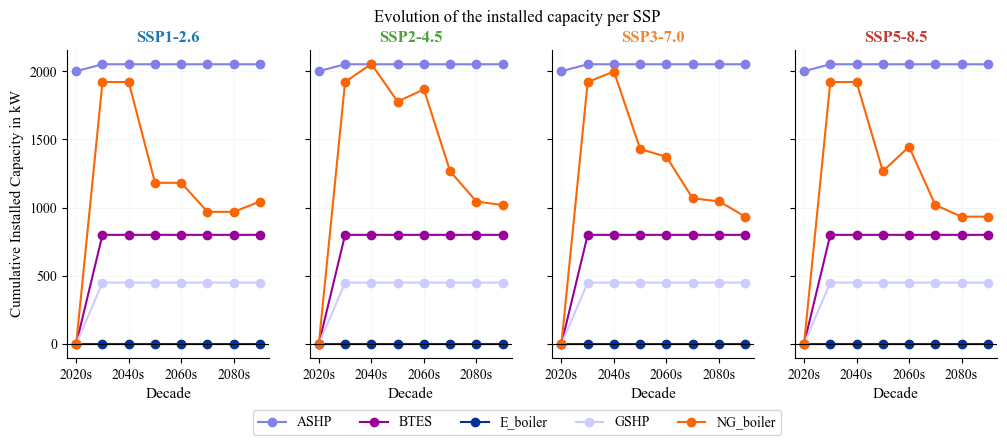

In [4]:

# Heating efficiency GSHP: 5.0601116056080215
# Heating efficiency NG_boiler: 1.10765
# Heating efficiency ASHP: 4.724079862225596
# Heating efficiency E_boiler: 1.0

# Cooling efficiency ASHP: 7.265079999999998
# Cooling efficiency GSHP: 10.0

# heating_eff = {'GSHP':5.0601116056080215,
#                'ASHP':4.724079862225596,
#                'E_boiler':1.10765,
#                'NG_boiler':1.0,
#                'BTES':1.0}
fig, axes = plt.subplots(1, len(ssps), figsize=(3*len(ssps), 4), sharey=True)
if len(ssps) == 1:
    axes = [axes]

for idx, ssp in enumerate(ssps):
    ax = axes[idx]
    mask = (df_invest['SSP']==ssp) | (df_invest['SSP']=='past')
    df_pivot = df_invest[mask].pivot(
        columns='Technology',
        index='Decade', 
        values='CumulativeCapacity'
    )
    for col in df_pivot.columns:
        df_pivot[[col]] = df_pivot[[col]] # * heating_eff[col]

    
    df_pivot.plot(ax = ax, legend=False, 
                  color=[tech_colors[column] for column in df_pivot.columns], 
                  marker = 'o')
    ssp_formatted = f"SSP{ssp[3]}-{ssp[4]}.{ssp[5]}"
    ax.set_title(f'{ssp_formatted}', fontdict={'color':ssp_colors[ssp_formatted]})
    ax.set_xlabel('Decade')
    if idx == 0:
        ax.set_ylabel('Cumulative Installed Capacity in kW')
    ax.axhline(y=0, color='black', linewidth=0.8)
    # ax.set_xticks(decades)
    # ax.set_xticklabels(decades, rotation=45, ha='right')
    # Remove the top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    # ax.set_ylim(0,3000)
    ax.grid(True)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(techs), bbox_to_anchor=(0.5, -0.1))
fig.suptitle('Evolution of the installed capacity per SSP')
plt.savefig('output/design/installed_capacities.png', dpi = 600, bbox_inches='tight')
plt.savefig('output/design/installed_capacities.pdf', bbox_inches='tight')
